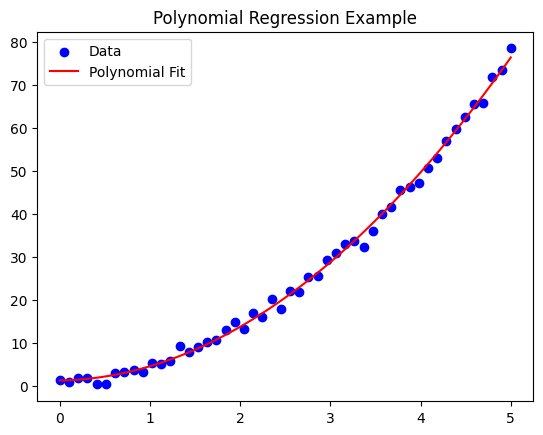

In [2]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
import numpy as np 
import matplotlib.pyplot as plt

# Sample data
X = np.linspace(0, 5, 50).reshape(-1, 1)
y = 3 * X.squeeze()**2 + 2 + np.random.randn(50)

# Polynomial Regression (degree 2)
model = make_pipeline(PolynomialFeatures(2), LinearRegression())
model.fit(X, y)

# Prediction
x_fit = np.linspace(0, 5, 100).reshape(-1, 1)
y_fit = model.predict(x_fit)

# Plot
plt.scatter(X, y, color='blue', label='Data')
plt.plot(x_fit, y_fit, color='red', label='Polynomial Fit')
plt.legend()
plt.title("Polynomial Regression Example")
plt.show()


#### Visualizing polynomial

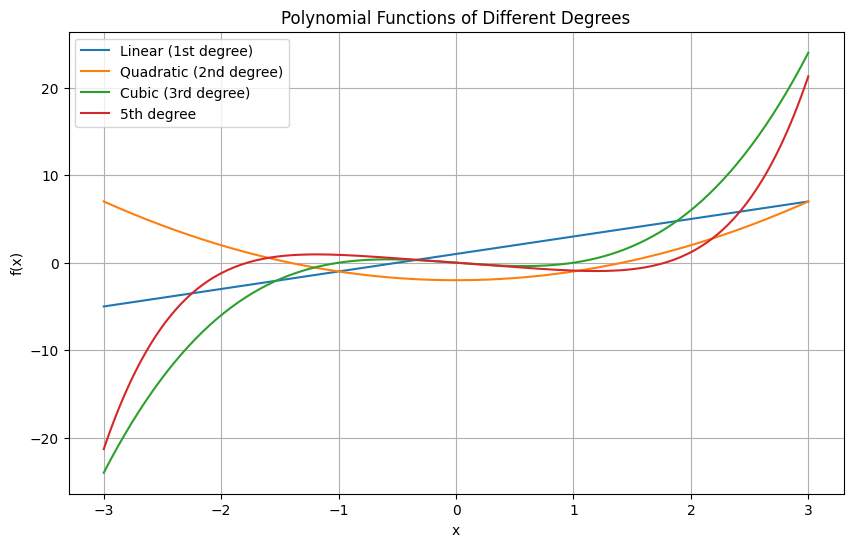

In [3]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-3, 3, 200)

plt.figure(figsize=(10, 6))

plt.plot(x, 2*x + 1, label="Linear (1st degree)")
plt.plot(x, x**2 - 2, label="Quadratic (2nd degree)")
plt.plot(x, x**3 - x, label="Cubic (3rd degree)")
plt.plot(x, 0.1*x**5 - x, label="5th degree")

plt.title("Polynomial Functions of Different Degrees")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True)
plt.legend()
plt.show()


##### Build a multi-class classification model using polynomial features from scratch in Python using Scikit-learn
##### What We'll Do:

- Generate synthetic multi-class data (nonlinear)
- Add polynomial features
- Train a Logistic Regression model
- Visualize decision boundaries
- Understand what's happening

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_blobs
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split


#### Create Nonlinear Multi-Class Data

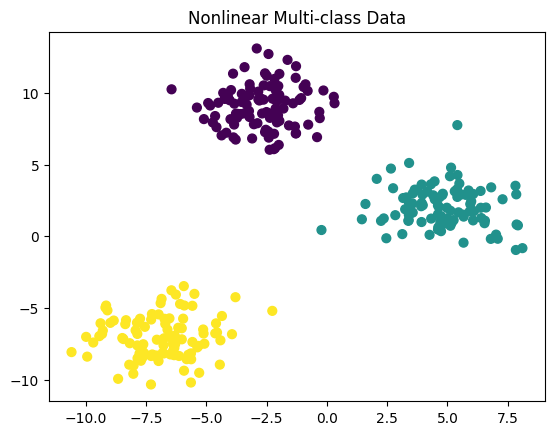

In [5]:
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=300,
                  centers=3,
                  random_state=42,
                  cluster_std=1.5)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', s=40)
plt.title("Nonlinear Multi-class Data")
plt.show()


#### Train Logistic Regression (Without Polynomials)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Just normal Logistic Regression
model_linear = LogisticRegression(multi_class='ovr', solver='lbfgs')
model_linear.fit(X_train, y_train)

print("Accuracy without polynomial features:", model_linear.score(X_test, y_test))

Accuracy without polynomial features: 1.0


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


#### Train with Polynomial Features

In [7]:
# Now with Polynomial Features
model_poly = make_pipeline(
    PolynomialFeatures(degree=3),  # Add x², x³, xy terms
    LogisticRegression(multi_class='ovr', solver='lbfgs', max_iter=1000)
)

model_poly.fit(X_train, y_train)

print("Accuracy with polynomial features:", model_poly.score(X_test, y_test))


Accuracy with polynomial features: 1.0


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


#### Visualize Decision Boundaries

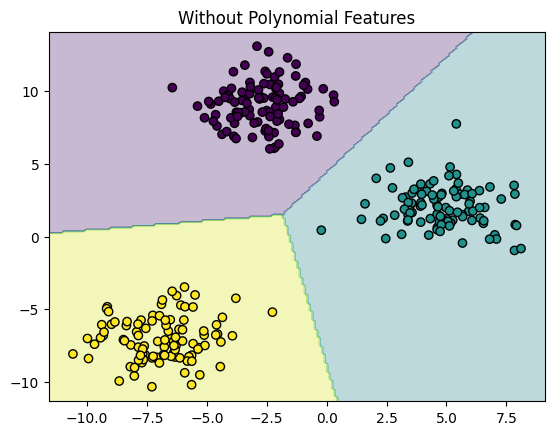

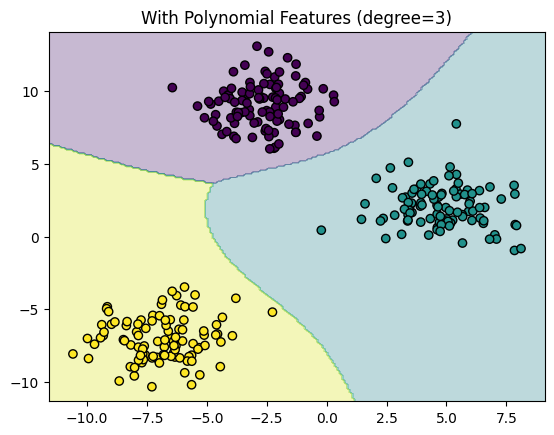

In [8]:
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, cmap='viridis', alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolors='k')
    plt.title(title)
    plt.show()

plot_decision_boundary(model_linear, X, y, "Without Polynomial Features")
plot_decision_boundary(model_poly, X, y, "With Polynomial Features (degree=3)")
